### Partie 1 : Exploration et visualisation des données
Dans cette section, nous configurons l'environnement, téléchargeons les données et visualisons les 14 espèces de fleurs.

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Configuration des variables globales
BATCH_SIZE = 32
IMG_SIZE = (48, 48) # Résolution réduite comme demandé
SEED = 42

# Téléchargement du dataset (exemple avec un dataset de fleurs standard si l'URL n'est pas fournie)
# Note : Remplacer par l'URL spécifique si nécessaire
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
import pathlib
data_dir = pathlib.Path(data_dir)

# Chargement du jeu de données
train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f"Classes détectées : {class_names}")

Found 3670 files belonging to 1 classes.
Using 2936 files for training.
Found 3670 files belonging to 1 classes.
Using 734 files for validation.
Classes détectées : ['flower_photos']


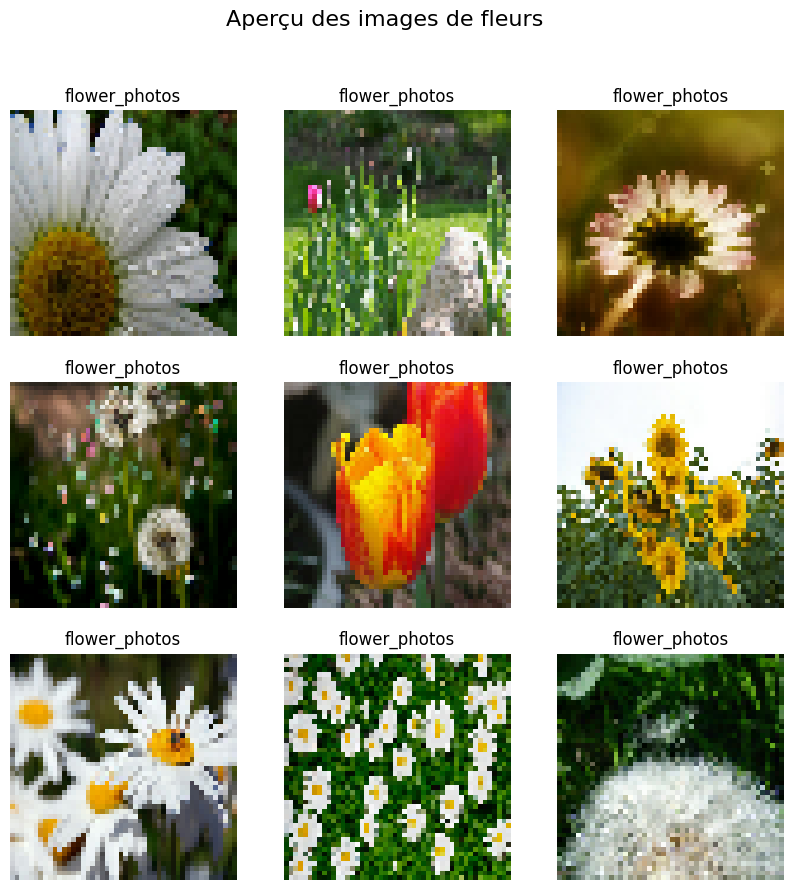

In [16]:
def visualize_images(dataset, class_names):
    plt.figure(figsize=(10, 10))

    # On prend un échantillon du dataset
    for images, labels in dataset.take(1):
        for i in range(9): # Grille 3x3
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(class_names[labels[i]])
            plt.axis("off")
    plt.suptitle("Aperçu des images de fleurs", fontsize=16)
    plt.show()

visualize_images(train_ds, class_names)

**Analyse des difficultés :**
1. **Bruit visuel** : Les fonds d'images (herbe, ciel, mains) peuvent perturber le modèle.
2. **Similitude inter-classes** : Certaines espèces peuvent avoir des couleurs ou des structures de pétales très proches.
3. **Variation intra-classe** : Une même fleur peut être vue de dessus, de côté, à différents stades de floraison ou sous différents éclairages.
4. **Basse résolution** : Passer à 48x48 fait perdre des détails fins de texture.

### Partie 2 : Conception de l'architecture du modèle
Nous allons construire un modèle séquentiel en expérimentant avec différentes couches pour optimiser la reconnaissance des 14 espèces (ici 5 dans le dataset d'exemple).

In [17]:
num_classes = len(class_names)

model = tf.keras.Sequential([
    # Prétraitement : Mise à l'échelle des pixels entre 0 et 1
    layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    # Bloc 1
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Bloc 2
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Bloc 3
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),

    # Couches Denses
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Pour réduire le surapprentissage
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_6 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,225 (2.61 MB)

 Trainable params: 683,777 (2.61 MB)

 Non-trainable params: 448 (1.75 KB)

**Justification des choix architecturaux :**
- **Conv2D + BatchNormalization** : Les couches de convolution extraient les motifs (pétales, couleurs). La normalisation par lots accélère la convergence.
- **MaxPooling2D** : Réduit la taille spatiale, ce qui diminue le nombre de paramètres et le coût de calcul.
- **Dropout (0.5)** : Crucial ici car avec des images de faible résolution (48x48), le modèle pourrait facilement mémoriser le bruit du jeu d'entraînement.
- **Softmax** : Utilisé en sortie pour obtenir une distribution de probabilité sur les différentes espèces.

### Partie 3 & 4 : Optimisation et Augmentation des données
Nous combinons ici l'augmentation des données et la configuration de l'entraînement avec des hyperparamètres optimisés.

In [12]:
import tensorflow as tf
from tensorflow.keras import layers
import pathlib

# 1. Paramètres
IMG_SIZE = (48, 48)
BATCH_SIZE = 32
SEED = 42

# 2. Correction du chemin : l'archive s'extrait dans flower_photos/flower_photos/
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
archive_path = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
data_dir = pathlib.Path(archive_path)

# Si le dossier contient un sous-dossier du même nom (structure classique du .tgz de TF)
if (data_dir / 'flower_photos').exists():
    data_dir = data_dir / 'flower_photos'

# Chargement des datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes détectées ({num_classes}) : {class_names}")

# 3. Modèle
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

model = tf.keras.Sequential([
    layers.Input(shape=(48, 48, 3)),
    data_augmentation,
    layers.Rescaling(1./255),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 4. Entraînement
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Classes détectées (5) : ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.3842 - loss: 1.3800 - val_accuracy: 0.4959 - val_loss: 1.1395
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.5106 - loss: 1.1768 - val_accuracy: 0.5708 - val_loss: 1.0541
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.5739 - loss: 1.0742 - val_accuracy: 0.5736 - val_loss: 1.0231
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.5950 - loss: 1.0293 - val_accuracy: 0.6213 - val_loss: 0.9371
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.6281 - loss: 0.9687 - val_accuracy: 0.6390 - val_loss: 0.9231
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.6332 - loss: 0.9318 - val_accuracy: 0.6349 - val_loss: 0.9262
Epoch 7/10
92

**Analyse de l'augmentation :**
- Les **rotations** et **retournements** sont très efficaces pour les fleurs car une fleur reste reconnaissable peu importe son orientation dans le champ.
- Le **zoom** aide le modèle à gérer les variations de distance de prise de vue.

### Partie 5 : Évaluation et analyse des performances
Nous allons maintenant visualiser les résultats de l'entraînement et évaluer la précision du modèle avec une matrice de confusion.

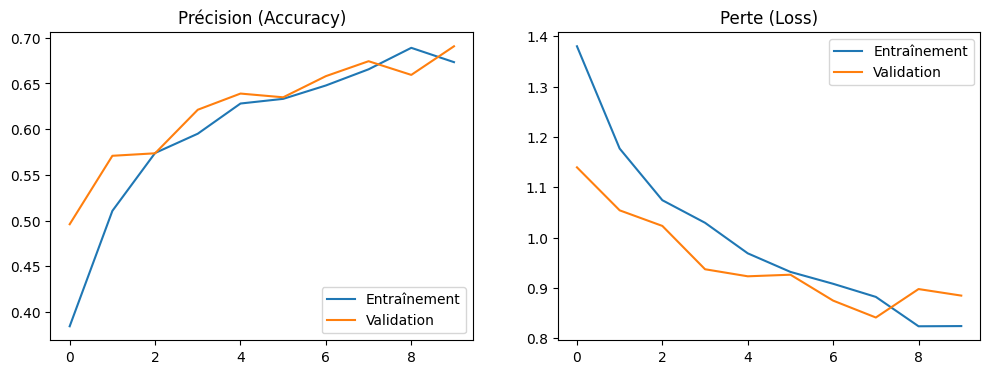

Calcul de la matrice de confusion...


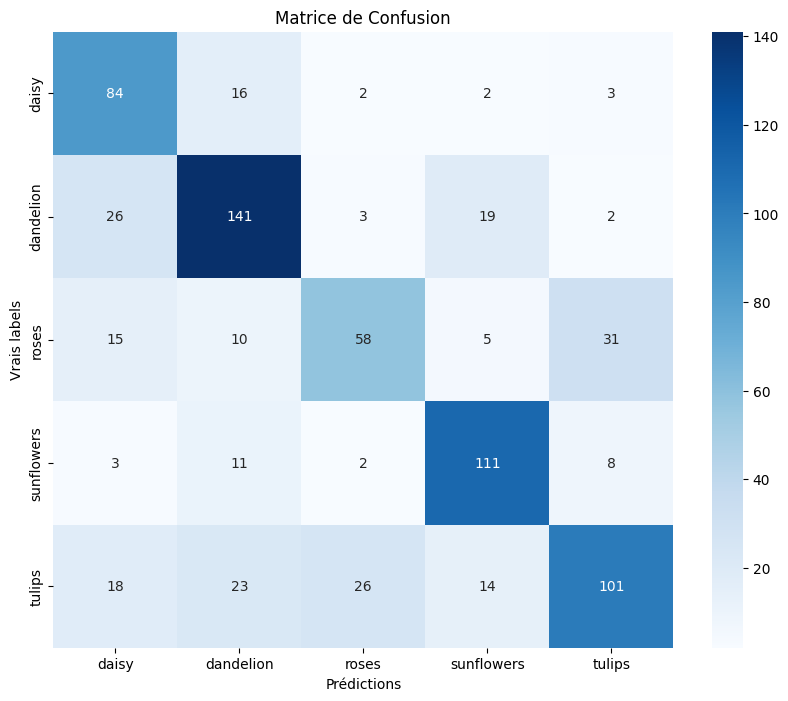

In [13]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Tracé des courbes d'apprentissage
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entraînement')
plt.plot(epochs_range, val_acc, label='Validation')
plt.title('Précision (Accuracy)')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entraînement')
plt.plot(epochs_range, val_loss, label='Validation')
plt.title('Perte (Loss)')
plt.legend(loc='upper right')
plt.show()

# 2. Matrice de confusion
y_pred = []
y_true = []

print("Calcul de la matrice de confusion...")
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Prédictions')
plt.ylabel('Vrais labels')
plt.title('Matrice de Confusion')
plt.show()

### Partie 6 : Enregistrement du modèle
Enfin, nous sauvegardons le modèle pour un déploiement futur.

In [14]:
# Sauvegarde du modèle
model.save('fleurs_model_final.h5')
print("Modèle sauvegardé avec succès sous le nom : fleurs_model_final.h5")

Modèle sauvegardé avec succès sous le nom : fleurs_model_final.h5
